In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("tkcm/results_shifted.csv")

print(df.head())

   mode metric  k   l  d  alpha  index      real      pred     error
0  mean     l2  3  12  3    0.5   3447  0.970043  0.973119  0.003075
1  mean     l2  3  12  3    0.5   3448  0.971529  0.974253  0.002724
2  mean     l2  3  12  3    0.5   3449  0.973192  0.974467  0.001275
3  mean     l2  3  12  3    0.5   3450  0.974923  0.971597  0.003327
4  mean     l2  3  12  3    0.5   3451  0.976593  0.970614  0.005979


In [27]:
df.groupby("mode")["error"].mean()

mode
mean            0.039318
weighted_exp    0.038654
weighted_inv    0.037797
Name: error, dtype: float64

In [28]:
df.groupby("mode")["error"].describe()

,count,mean,std,min,25%,50%,75%,max
mode,,,,,,,,
mean,51780.0,0.039318,0.054597,0.000000,0.004886,0.013015,0.051041,0.320795
weighted_exp,51780.0,0.038654,0.054505,0.000000,0.004723,0.012528,0.049106,0.320598
weighted_inv,51780.0,0.037797,0.054347,0.000001,0.004536,0.011971,0.046449,0.318864


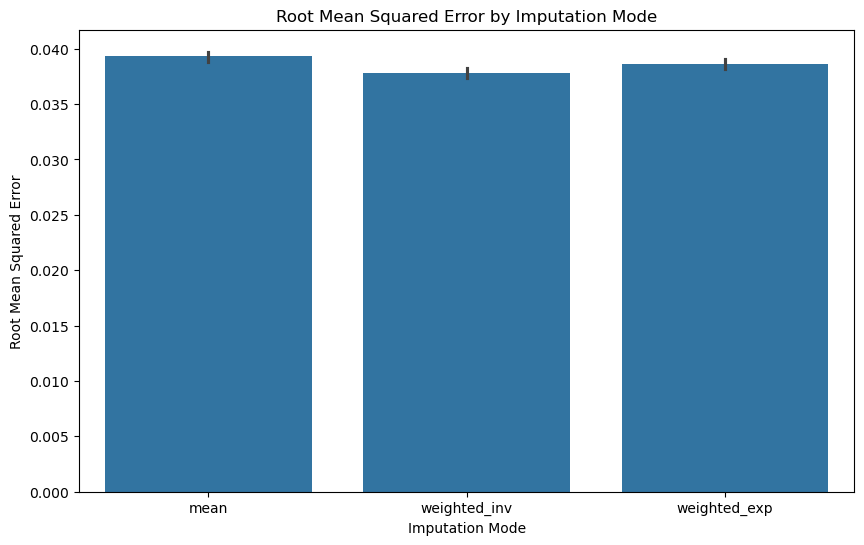

In [29]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="mode", y="error", data=df)
plt.title("Root Mean Squared Error by Imputation Mode")
plt.ylabel("Root Mean Squared Error")
plt.xlabel("Imputation Mode")
plt.savefig('figures_shifted/imputation_mode_rmse.png')
plt.show()


In [30]:
# rank the grouped results by error
grouped_df = df.groupby(["mode", "k", "l"])["error"].mean().reset_index()
sorted_df = grouped_df.sort_values("error")
sorted_df.head()

,mode,k,l,error
39,weighted_exp,9,96,0.035243
59,weighted_inv,9,96,0.035390
58,weighted_inv,9,72,0.035441
44,weighted_inv,3,96,0.035547
34,weighted_exp,7,96,0.035599


In [31]:
# best parameter combination per mode
best_params = grouped_df.loc[
    grouped_df.groupby("mode")["error"].idxmin()
]
print("Shifted chlorine dataset results:")
print("Best parameter combinations per mode:")
print(best_params)
worst_params = grouped_df.loc[
    grouped_df.groupby("mode")["error"].idxmax()
]
print("Worst parameter combinations per mode:")
print(worst_params)

Shifted chlorine dataset results:
Best parameter combinations per mode:
            mode  k   l     error
0           mean  3  12  0.036065
39  weighted_exp  9  96  0.035243
59  weighted_inv  9  96  0.035390
Worst parameter combinations per mode:
            mode  k   l     error
2           mean  3  48  0.043884
22  weighted_exp  3  48  0.043049
41  weighted_inv  3  24  0.042533


In [32]:
best_params_dict = {}

for mode in best_params["mode"].unique():
    row = best_params[best_params["mode"] == mode].iloc[0]
    k = row["k"]
    l = row["l"]
    mode = row["mode"]
    print(f"Best parameters for mode {mode}: k={row['k']}, l={row['l']} with error={row['error']}")
    # store the best parameters for each mode in a dictionary
    best_params_dict[mode] = {"k": k, "l": l}

worst_params_dict = {}
for mode in worst_params["mode"].unique():
    row = worst_params[worst_params["mode"] == mode].iloc[0]
    k = row["k"]
    l = row["l"]
    mode = row["mode"]
    print(f"Worst parameters for mode {mode}: k={row['k']}, l={row['l']} with error={row['error']}")
    # store the worst parameters for each mode in a dictionary
    
    worst_params_dict[mode] = {"k": k, "l": l}

Best parameters for mode mean: k=3, l=12 with error=0.03606453572808034
Best parameters for mode weighted_exp: k=9, l=96 with error=0.035242853611432985
Best parameters for mode weighted_inv: k=9, l=96 with error=0.035390025106218616
Worst parameters for mode mean: k=3, l=48 with error=0.0438836786404017
Worst parameters for mode weighted_exp: k=3, l=48 with error=0.04304895712630359
Worst parameters for mode weighted_inv: k=3, l=24 with error=0.042533397064503674


In [33]:
best_params_dict

{'mean': {'k': np.int64(3), 'l': np.int64(12)},
 'weighted_exp': {'k': np.int64(9), 'l': np.int64(96)},
 'weighted_inv': {'k': np.int64(9), 'l': np.int64(96)}}

In [34]:
worst_params_dict

{'mean': {'k': np.int64(3), 'l': np.int64(48)},
 'weighted_exp': {'k': np.int64(3), 'l': np.int64(48)},
 'weighted_inv': {'k': np.int64(3), 'l': np.int64(24)}}

In [35]:
best_runs = df.merge(best_params, on=["mode", "k", "l"], how="inner")
worst_runs = df.merge(worst_params, on=["mode", "k", "l"], how="inner")


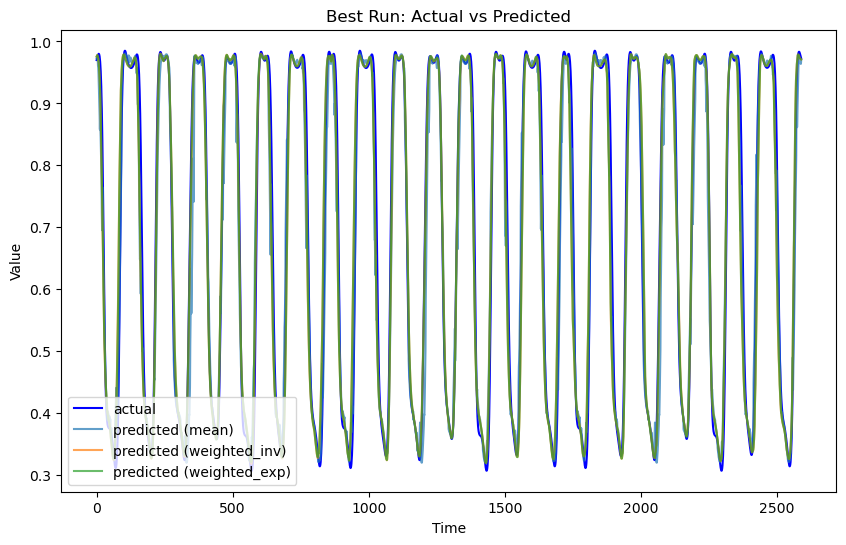

In [36]:
real_ts = best_runs[best_runs["mode"] == "mean"]["real"].to_numpy()
plt.figure(figsize=(10,6))
plt.plot(real_ts, label="actual", color="blue")
for mode in best_runs["mode"].unique():
    predicted_ts = best_runs[best_runs["mode"] == mode]["pred"].to_numpy()
    plt.plot(predicted_ts, label=f"predicted ({mode})", alpha=0.7)

plt.title("Best Run: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='lower left')
plt.savefig('figures_shifted/best_run_predictions.png')
plt.show()


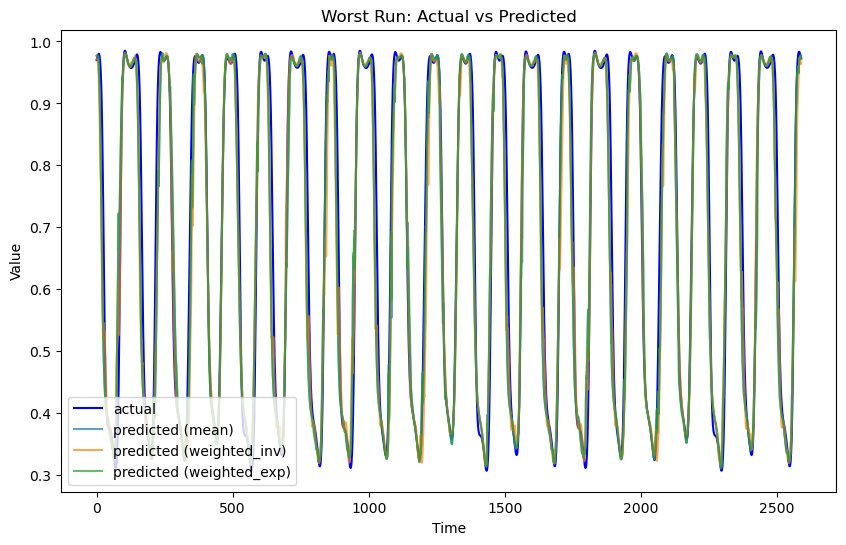

In [37]:
plt.figure(figsize=(10,6))
plt.plot(real_ts, label="actual", color="blue")
for mode in worst_runs["mode"].unique():
    predicted_ts = worst_runs[worst_runs["mode"] == mode]["pred"].to_numpy()
    plt.plot(predicted_ts, label=f"predicted ({mode})", alpha=0.7)

plt.title("Worst Run: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='lower left')
plt.savefig('figures_shifted/worst_run_predictions.png')
plt.show()


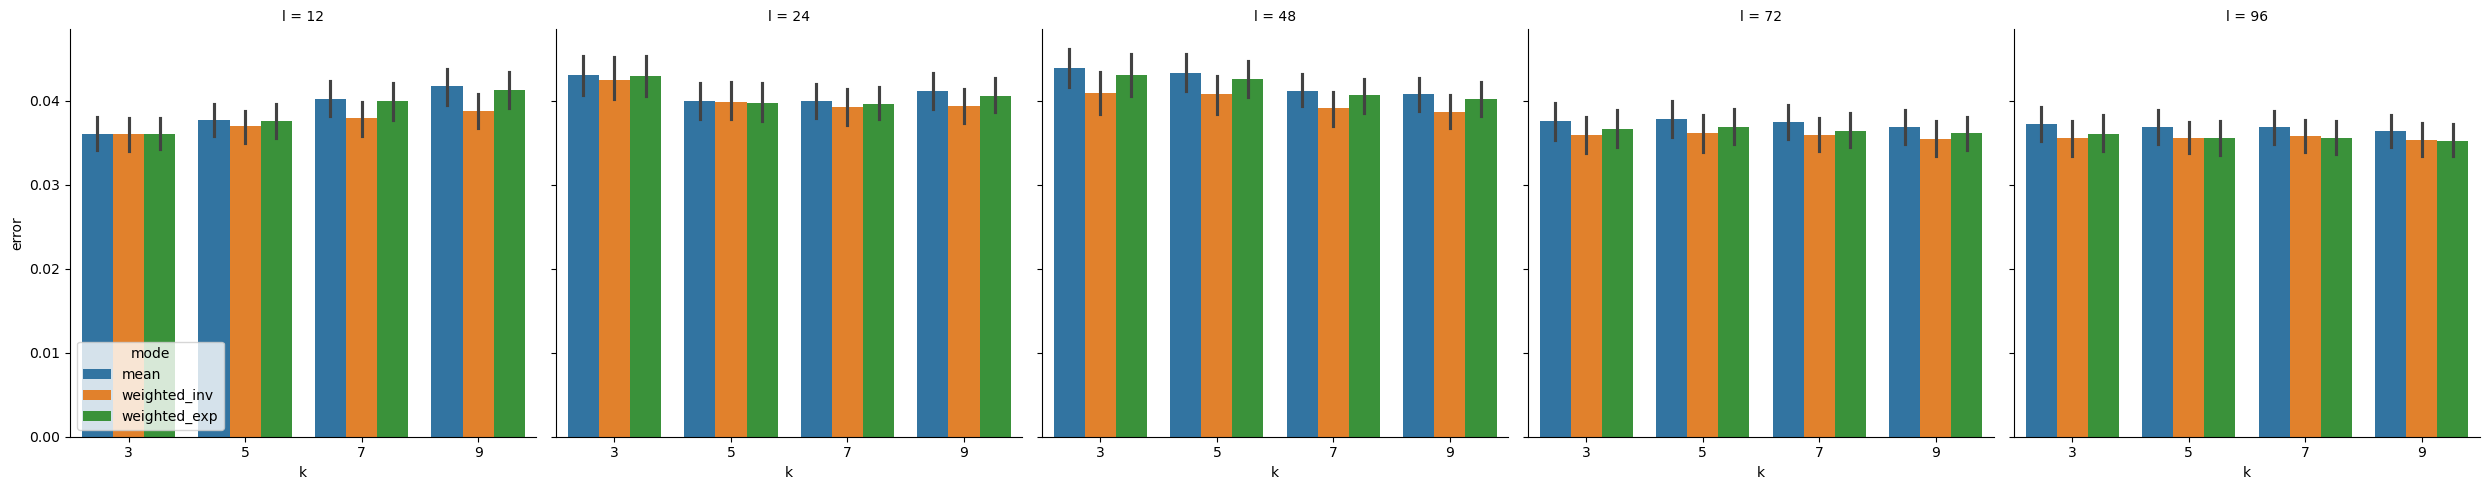

In [38]:
# plot the error for each mode as a function of k and l
sns.catplot(
    data=df,
    x="k",
    y="error",
    hue="mode",
    col="l",
    kind="bar",
    legend_out=False,
)
plt.savefig('figures_shifted/error_by_k_l_mode.png')
plt.show()


In [39]:
# get the first 4 time series from cl2fullLarge_shifted.dat
data = np.loadtxt("tkcm/cl2fullLarge_shifted.dat")
first_4_ts = data[:, :4]

best_predicted_ts = best_runs[best_runs["mode"] == "weighted_inv"]["pred"].to_numpy()
start = 3300
predicted_padded = np.full_like(first_4_ts[start:, 0], np.nan)
predicted_padded[len(predicted_padded)-len(best_predicted_ts):] = best_predicted_ts
# plot the first 4 time series 
plt.figure(figsize=(10,6))
for i in range(4):
    plt.plot(first_4_ts[start:, i], label=f"TS" if i == 0 else f"RF {i}", alpha=0.7)
# plot the predicted values for the best run on top of the actual values
plt.plot(predicted_padded, label="Best Run Predicted (mean)", color="black", alpha=0.7)
plt.title("First 4 Time Series from Shifted Dataset")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='upper right')
plt.savefig('figures_shifted/first_4_time_series.png')
plt.show()

ValueError: could not broadcast input array from shape (2589,) into shape (1010,)

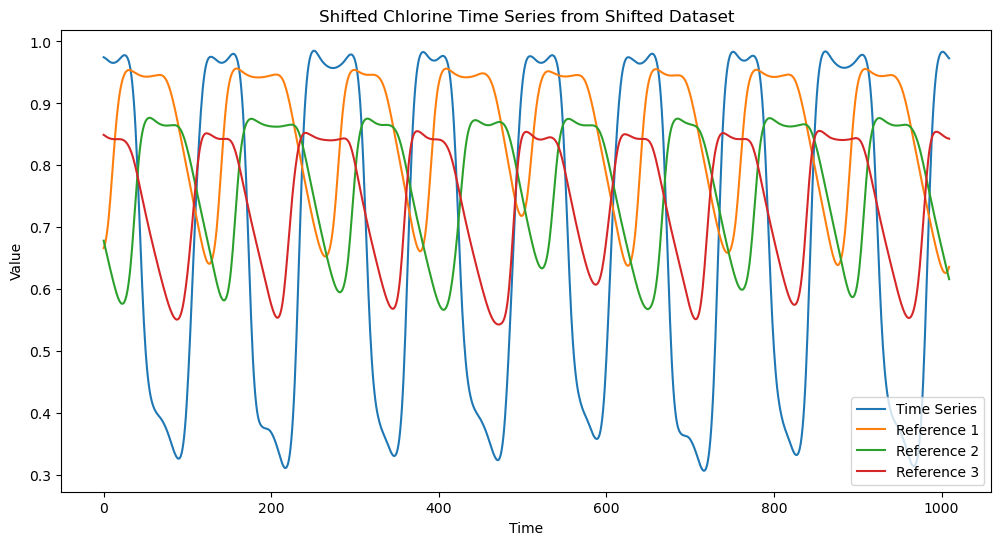

In [40]:
# plot the first 4 time series 
plt.figure(figsize=(12,6))
for i in range(4):
    plt.plot(first_4_ts[start:, i], label=f"Time Series" if i == 0 else f"Reference {i}")
plt.title("Shifted Chlorine Time Series from Shifted Dataset")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='lower right')
plt.savefig('figures_shifted/first_4_time_series.png')
plt.show()

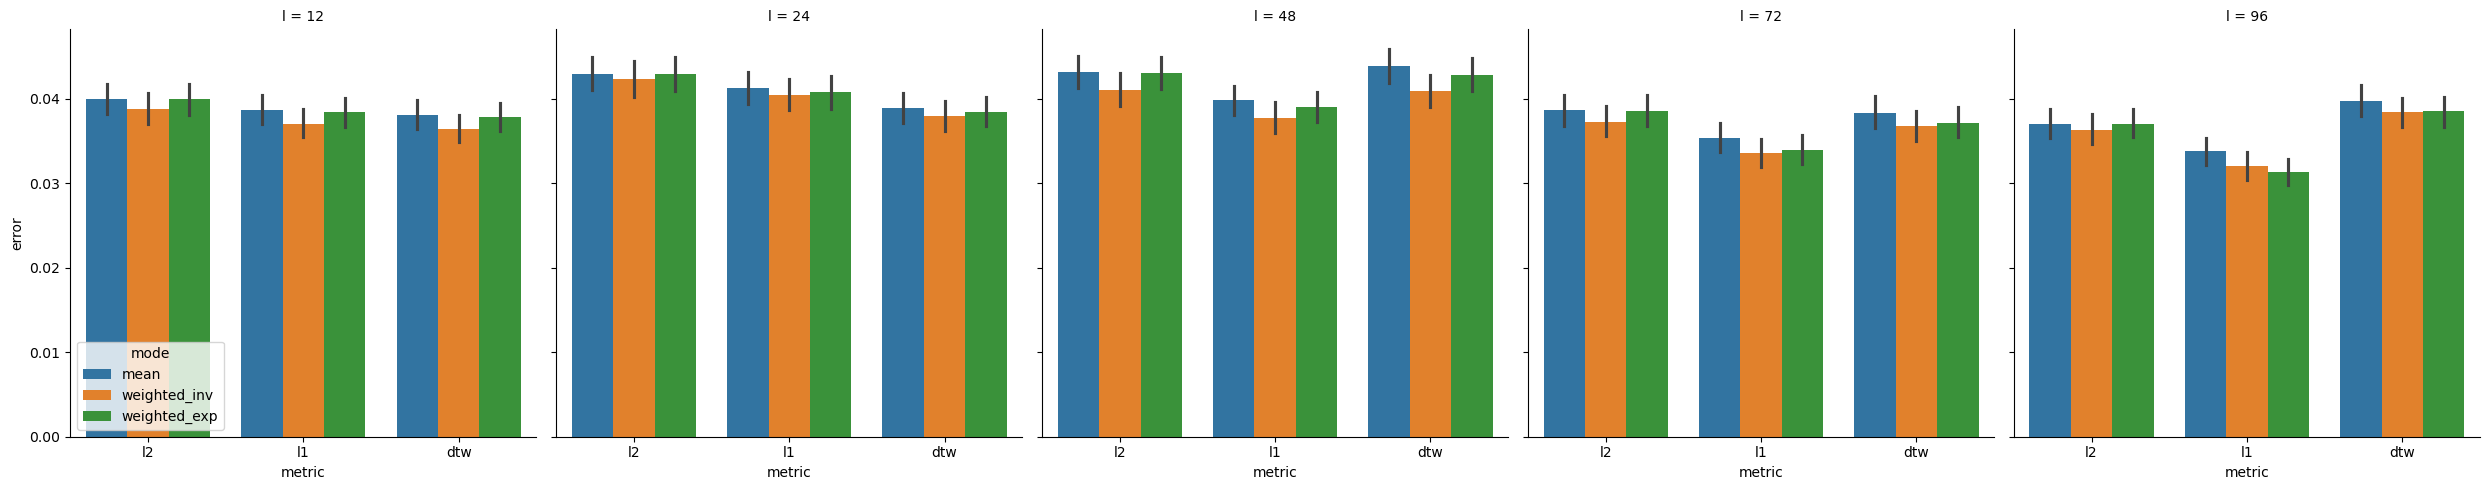

In [41]:
# plot the error for each mode as a function of k and l
sns.catplot(
    data=df,
    x="metric",
    y="error",
    hue="mode",
    col="l",
    kind="bar",
    legend_out=False,
)
plt.savefig('figures_shifted/error_by_metric_l_mode.png')
plt.show()


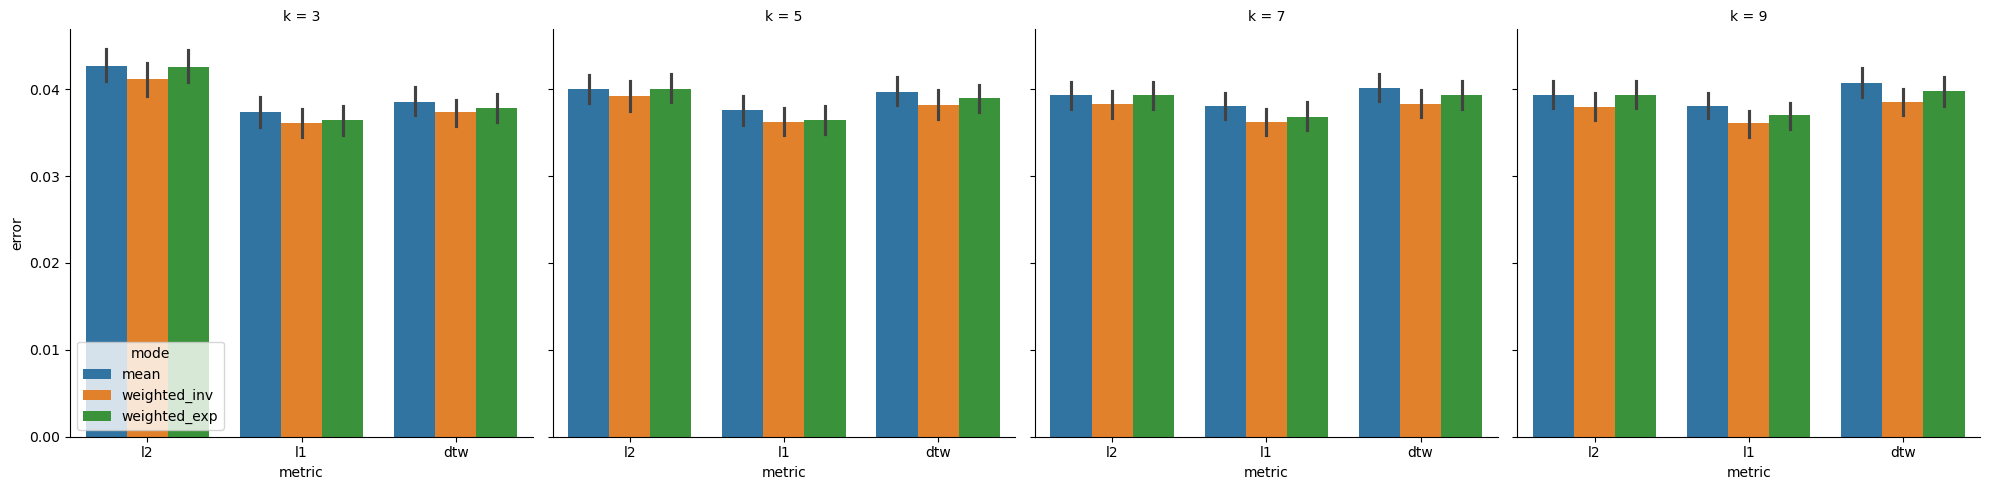

In [42]:
sns.catplot(
    data=df,
    x="metric",
    y="error",
    hue="mode",
    col="k",
    kind="bar",
    legend_out=False,
)
plt.savefig('figures_shifted/error_by_metric_k_mode.png')
plt.show()

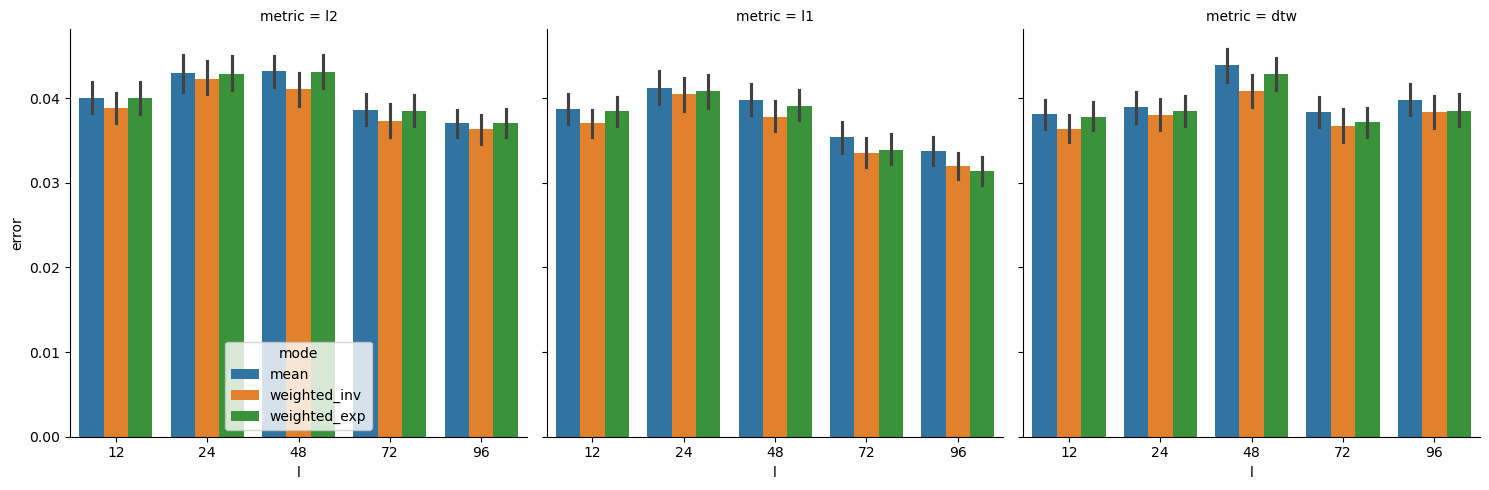

In [46]:
sns.catplot(
    data=df,
    x="l",
    y="error",
    hue="mode",
    col="metric",
    kind="bar",
    legend_out=False,
)
plt.savefig('figures_shifted/error_by_metric_k_mode.png')
plt.show()

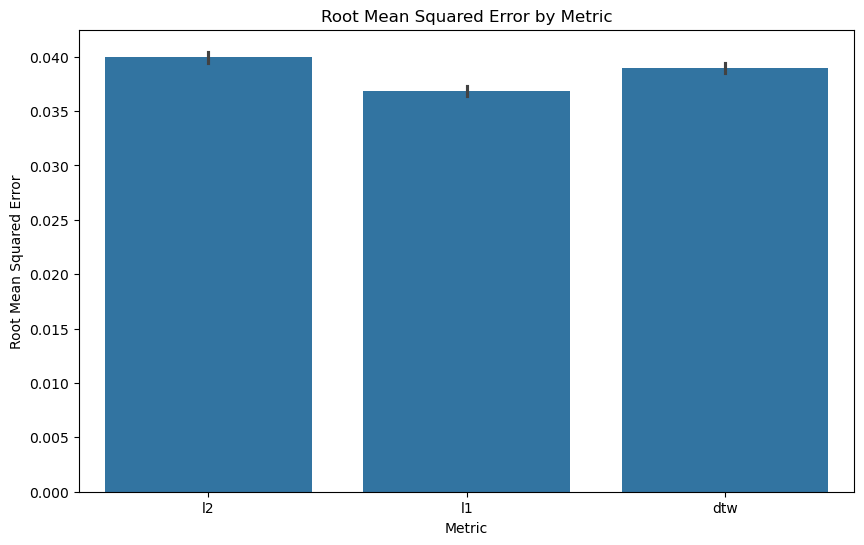

In [43]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="metric", y="error", data=df)
plt.title("Root Mean Squared Error by Metric")
plt.ylabel("Root Mean Squared Error")
plt.xlabel("Metric")
plt.savefig('figures_shifted/metric_rmse.png')
plt.show()

In [44]:
df.groupby(["metric", "mode"])["error"].mean()

metric  mode        
dtw     mean            0.039808
        weighted_exp    0.038961
        weighted_inv    0.038072
l1      mean            0.037784
        weighted_exp    0.036700
        weighted_inv    0.036152
l2      mean            0.040361
        weighted_exp    0.040302
        weighted_inv    0.039166
Name: error, dtype: float64

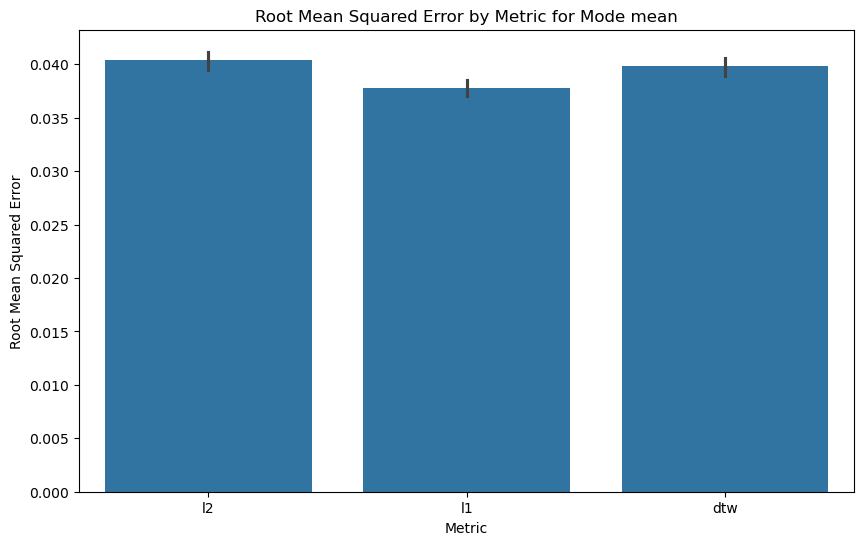

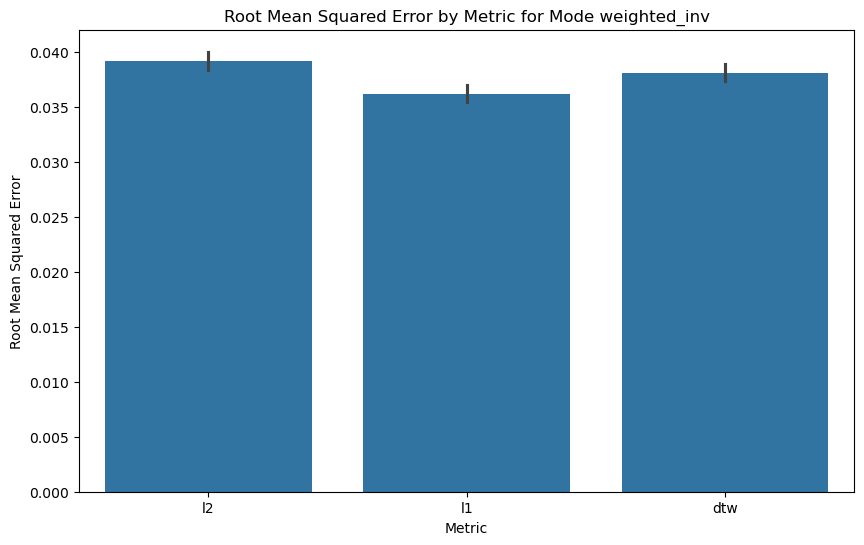

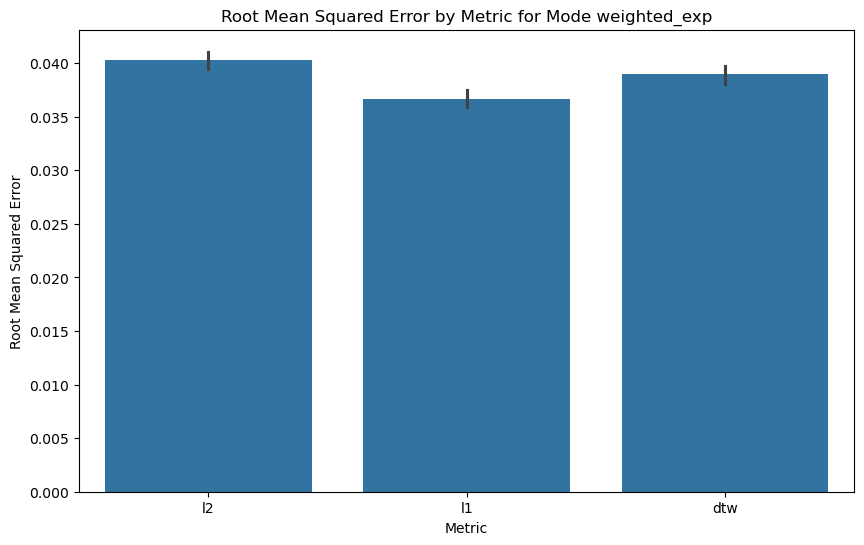

In [45]:
# for each mode, plot the error as a function of the metric
for mode in df["mode"].unique():
    mode_df = df[df["mode"] == mode]
    plt.figure(figsize=(10,6))
    sns.barplot(x="metric", y="error", data=mode_df)
    plt.title(f"Root Mean Squared Error by Metric for Mode {mode}")
    plt.ylabel("Root Mean Squared Error")
    plt.xlabel("Metric")
    plt.savefig(f'figures/error_by_metric_{mode}_mode.png')
    plt.show()